# Heart Disease Prediction

## 5. Unsupervised Learning - Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [2]:
df = pd.read_csv("heart_cleaned.csv")

X = df.drop(columns=["num"])
y = df["num"]

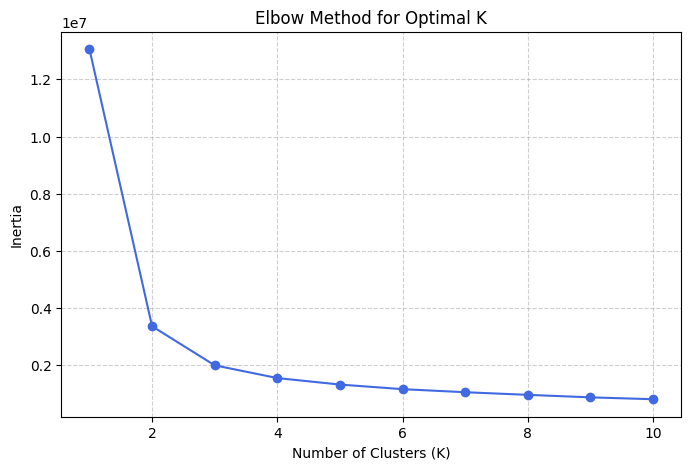

KMeans Adjusted Rand Index: 0.0930
KMeans Silhouette Score: 0.707441113612857


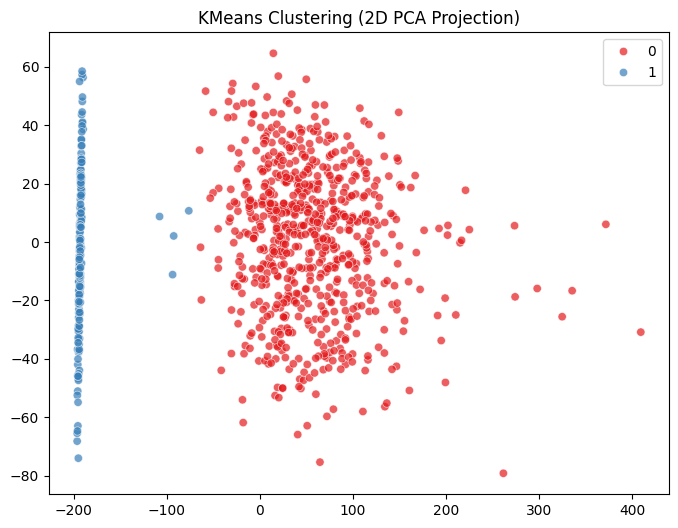

In [3]:
# K-Means Clustering
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker="o", color="royalblue")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Fit KMeans with chosen k 
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X).astype(int)   # ensure discrete labels

# Compare with true labels (only for evaluation, not training)
ari = adjusted_rand_score(y, kmeans_labels)
print(f"KMeans Adjusted Rand Index: {ari:.4f}")
print("KMeans Silhouette Score:", silhouette_score(X, kmeans_labels))

# Visualization (using 2 PCA components for clarity)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette="Set1", alpha=0.7)
plt.title("KMeans Clustering (2D PCA Projection)")
plt.show()

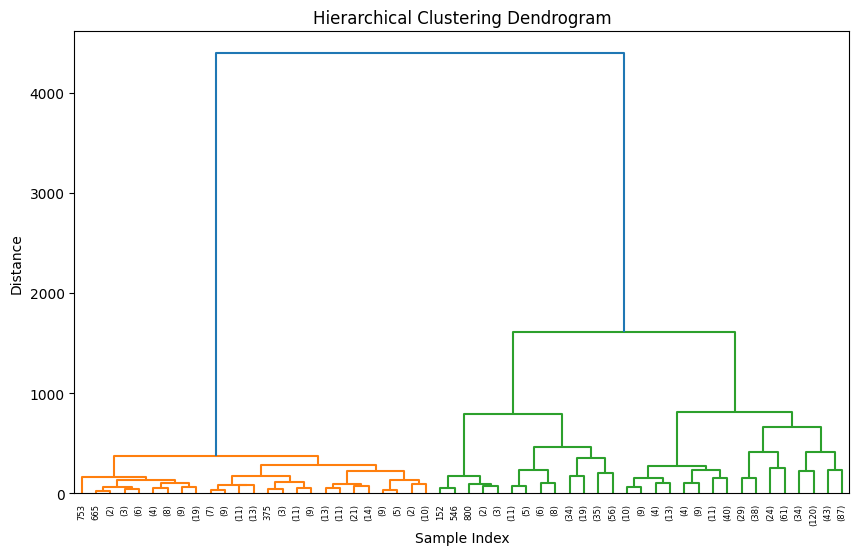

Hierarchical Adjusted Rand Index: 0.09506705183947897
Hierarchical Silhouette Score: 0.7068025096471523


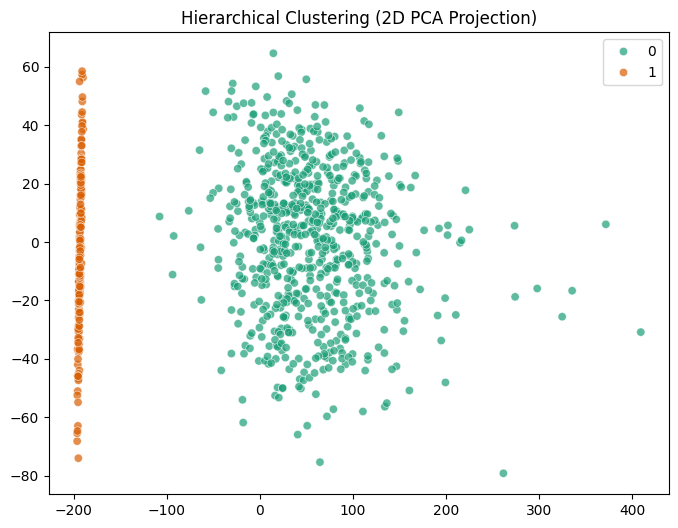

In [4]:
# Hierarchical Clustering
# Dendrogram
plt.figure(figsize=(10,6))
Z = linkage(X, method="ward")
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

# Agglomerative clustering with 2 clusters
agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
agg_labels = agg.fit_predict(X)

print("Hierarchical Adjusted Rand Index:", adjusted_rand_score(y, agg_labels))
print("Hierarchical Silhouette Score:", silhouette_score(X, agg_labels))

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=agg_labels, palette="Dark2", alpha=0.7)
plt.title("Hierarchical Clustering (2D PCA Projection)")
plt.show()

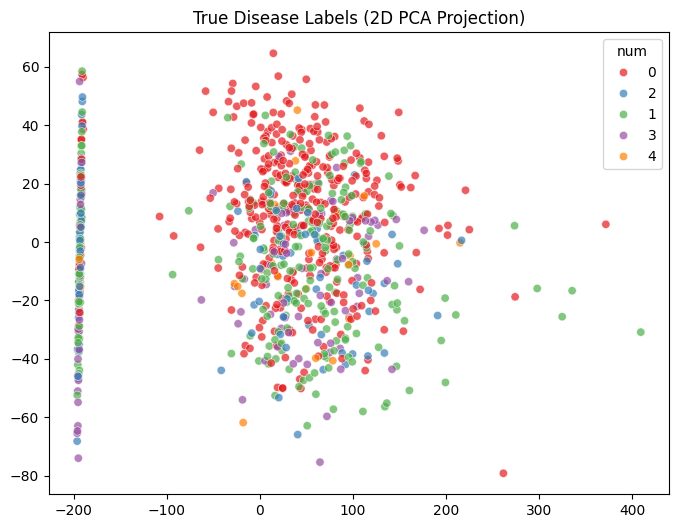

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0], 
    y=X_pca[:,1], 
    hue=y.astype(str),  # force categorical
    palette="Set1", 
    alpha=0.7
)
plt.title("True Disease Labels (2D PCA Projection)")
plt.show()